In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('semiconductor_yield_forecasting_data.csv')

In [3]:
df.head()

,lot_id,wafer_id,product_type,technology_node,process_date,etch_tool,litho_tool,deposition_tool,implant_tool,etch_rate,...,tilt_angle,critical_dimension,oxide_thickness,resistivity,defect_count,defect_density,vth,leakage_current,resistance,yield
0,LOT_0001,W001,CPU,10nm,2023-01-01,ETCH_02,LITHO_01,DEP_03,IMP_01,3.559737,...,6.768291,21.301405,55.604906,1.926016,664,0.946658,0.557038,0.000353,90.022492,0.678783
1,LOT_0001,W002,CPU,10nm,2023-01-01,ETCH_02,LITHO_01,DEP_03,IMP_01,3.407016,...,6.682220,20.467672,54.595612,2.339905,612,0.811460,0.585546,0.000122,103.656821,0.779966
2,LOT_0001,W003,CPU,10nm,2023-01-01,ETCH_02,LITHO_01,DEP_03,IMP_01,3.413745,...,7.171809,19.355440,55.810210,2.384475,584,0.798226,0.624927,0.000357,95.053771,0.778492
3,LOT_0001,W004,CPU,10nm,2023-01-01,ETCH_02,LITHO_01,DEP_03,IMP_01,3.495263,...,6.962098,23.459445,56.988989,2.948630,673,0.952954,0.646799,0.000250,105.176477,0.405275
4,LOT_0001,W005,CPU,10nm,2023-01-01,ETCH_02,LITHO_01,DEP_03,IMP_01,3.526964,...,7.457701,22.493127,53.675599,2.653980,613,0.818124,0.571641,0.000198,98.917061,0.935350


In [4]:
print ('dataset shape: ', df.shape)

dataset shape:  (1250, 28)


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1250 entries, 0 to 1249
Data columns (total 28 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   lot_id                1250 non-null   object 
 1   wafer_id              1250 non-null   object 
 2   product_type          1250 non-null   object 
 3   technology_node       1250 non-null   object 
 4   process_date          1250 non-null   object 
 5   etch_tool             1250 non-null   object 
 6   litho_tool            1250 non-null   object 
 7   deposition_tool       1250 non-null   object 
 8   implant_tool          1250 non-null   object 
 9   etch_rate             1250 non-null   float64
 10  pressure              1250 non-null   float64
 11  temperature           1250 non-null   float64
 12  exposure_time         1250 non-null   float64
 13  focus_offset          1250 non-null   float64
 14  dose                  1250 non-null   float64
 15  deposition_rate      

In [6]:
df.describe()

,etch_rate,pressure,temperature,exposure_time,focus_offset,dose,deposition_rate,thickness_uniformity,implant_energy,tilt_angle,critical_dimension,oxide_thickness,resistivity,defect_count,defect_density,vth,leakage_current,resistance,yield
count,1250.000000,1250.000000,1250.000000,1250.000000,1250.000000,1.250000e+03,1250.000000,1250.000000,1250.000000,1250.000000,1250.000000,1250.000000,1250.000000,1250.000000,1250.000000,1250.000000,1250.000000,1250.000000,1250.000000
mean,3.615159,152.701008,66.769677,1.501329,0.027446,1.000095e+15,1.899942,1.702233,49.986779,7.001714,24.608270,56.984467,2.495853,682.777600,0.964839,0.644599,0.000373,100.715200,0.456679
std,0.100215,5.147463,2.193719,0.049894,0.006700,9.896583e+12,0.116487,0.236905,0.998741,0.498059,4.245067,4.654281,0.299258,87.338157,0.119583,0.067599,0.000238,6.307770,0.175306
min,3.304931,135.292927,60.328505,1.350315,0.008577,9.703325e+14,1.542779,0.875049,47.045751,5.462945,15.337494,44.595515,1.546989,403.000000,0.547276,0.464514,0.000058,80.608027,0.148086
25%,3.544830,149.232815,65.264264,1.467451,0.022930,9.930979e+14,1.827348,1.534593,49.289898,6.667923,21.255550,53.716388,2.289884,623.000000,0.880522,0.601040,0.000219,96.203866,0.323588
50%,3.612966,152.654285,66.722459,1.501331,0.026975,9.999683e+14,1.900440,1.700894,49.975520,7.000520,24.994991,57.351614,2.494975,682.500000,0.963671,0.643843,0.000315,100.616622,0.415796
75%,3.681864,156.160225,68.286453,1.534600,0.031890,1.006631e+15,1.979659,1.864622,50.684044,7.344025,28.109128,60.409474,2.690423,740.750000,1.047014,0.691697,0.000461,105.004190,0.573955
max,3.935599,168.342924,73.171970,1.670403,0.051468,1.033010e+15,2.259813,2.456949,53.806717,8.471524,34.232696,70.808496,3.528673,993.000000,1.344248,0.867928,0.002538,117.936695,0.982489


In [7]:
df.isnull().sum().sort_values(ascending=False)

lot_id                  0
wafer_id                0
resistance              0
leakage_current         0
vth                     0
defect_density          0
defect_count            0
resistivity             0
oxide_thickness         0
critical_dimension      0
tilt_angle              0
implant_energy          0
thickness_uniformity    0
deposition_rate         0
dose                    0
focus_offset            0
exposure_time           0
temperature             0
pressure                0
etch_rate               0
implant_tool            0
deposition_tool         0
litho_tool              0
etch_tool               0
process_date            0
technology_node         0
product_type            0
yield                   0
dtype: int64

In [8]:
#create a numeric dataframe
numeric_df = df.select_dtypes(include=['float64','int64'])

In [9]:
#calculate correlation
corr_matrix = numeric_df.corr()

In [10]:
#correlation with yield
yield_corr = corr_matrix['yield'].drop('yield').sort_values(key=abs, ascending=False)

In [11]:
print(yield_corr)

critical_dimension     -0.652517
vth                    -0.541121
oxide_thickness        -0.507109
resistance             -0.202320
defect_count           -0.122595
thickness_uniformity   -0.122551
defect_density         -0.119366
focus_offset            0.072350
dose                    0.057008
leakage_current        -0.046530
implant_energy          0.024474
resistivity             0.017502
deposition_rate        -0.014997
etch_rate              -0.006145
temperature            -0.004851
tilt_angle              0.003471
pressure               -0.003284
exposure_time          -0.000815
Name: yield, dtype: float64


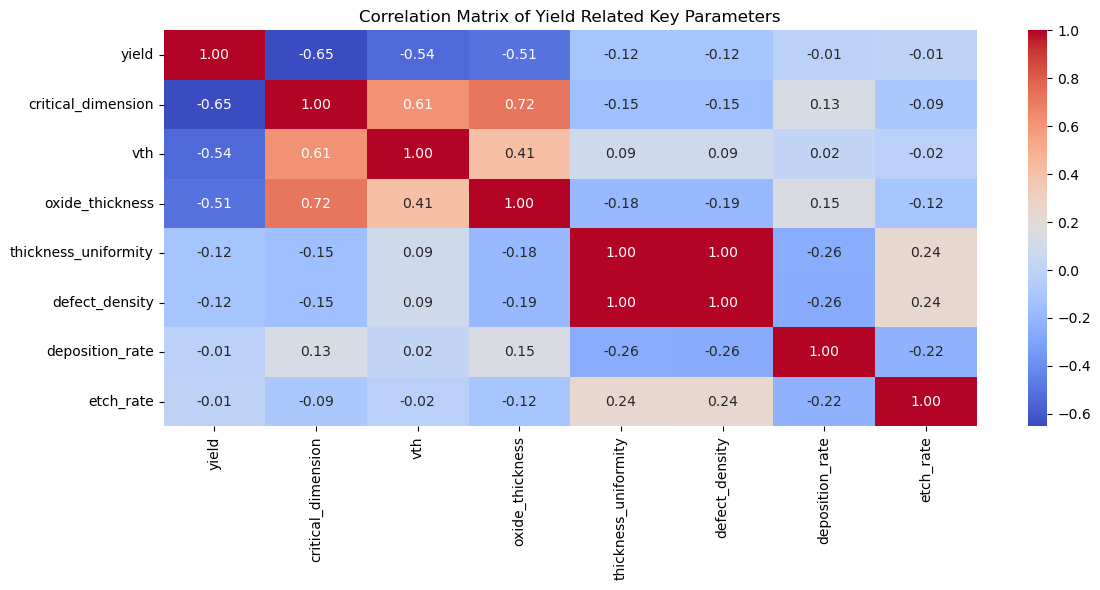

In [12]:
#create heatmap
key_col = ['yield','critical_dimension','vth','oxide_thickness','thickness_uniformity','defect_density','deposition_rate','etch_rate']
key_corr = df[key_col].corr()

plt.figure(figsize=(12,6))
sns.heatmap(key_corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Yield Related Key Parameters')
plt.tight_layout()
plt.show()